In [1]:
import deepchem as dc
import pickle

# Load dataset
with open("../models/dataset_split.pkl", "rb") as f:
    train_dataset, valid_dataset, test_dataset, transformers = pickle.load(f)

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading material featurizer, missing a dependency. No module named 'ase'


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers.models.roberta.tokenization_roberta_fast'
cannot import name 'Chemberta' from 'deepchem.models.torch_models' (/Users/sohanmulamalla/Desktop/Projects/soluscope-ai/venv/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/Users/sohanmulamalla/Desktop/Projects/soluscope-ai/venv/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'


In [2]:
model = dc.models.MultitaskRegressor(
    n_tasks=1,
    n_features=1024,
    layer_sizes=[500, 100],
    model_dir="../models/multitask_regressor"
)

In [3]:
model.restore()

In [4]:
metrics = [
    dc.metrics.Metric(dc.metrics.pearson_r2_score),
    dc.metrics.Metric(dc.metrics.mean_absolute_error),
    dc.metrics.Metric(dc.metrics.rms_score)
]

train_scores = model.evaluate(train_dataset, metrics, transformers)
valid_scores = model.evaluate(valid_dataset, metrics, transformers)
test_scores = model.evaluate(test_dataset, metrics, transformers)

print("Train:", train_scores)
print("Valid:", valid_scores)
print("Test:", test_scores)

Train: {'pearson_r2_score': 0.970788276951003, 'mean_absolute_error': 0.20326497336921023, 'rms_score': 0.3640372140911633}
Valid: {'pearson_r2_score': 0.6374268372028308, 'mean_absolute_error': 0.8869916405890259, 'rms_score': 1.243693376617792}
Test: {'pearson_r2_score': 0.6207621310575897, 'mean_absolute_error': 0.9895368205707398, 'rms_score': 1.360771133981504}


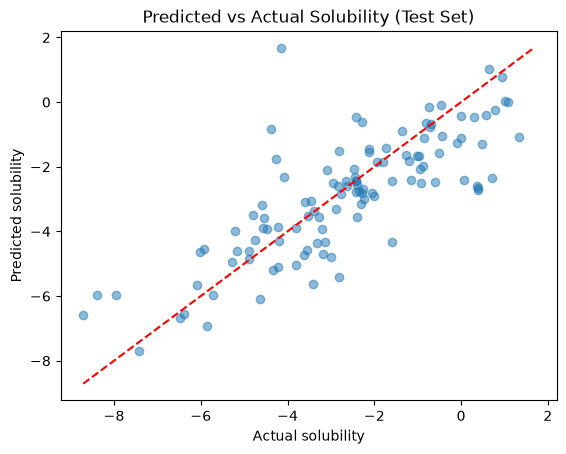

In [6]:
import matplotlib.pyplot as plt

y_true = transformers[0].untransform(test_dataset.y)
y_pred = model.predict(test_dataset, transformers=transformers)

plt.scatter(y_true.flatten(), y_pred.flatten(), alpha=0.5)

minimum = min(y_true.min(), y_pred.min())
maximum = max(y_true.max(), y_pred.max())

plt.plot([minimum, maximum], [minimum, maximum], "r--")

plt.xlabel("Actual solubility")
plt.ylabel("Predicted solubility")
plt.title("Predicted vs Actual Solubility (Test Set)")
plt.show()